## 1.Выбор набора данных
Выберем набор данных из второй лабораторной

In [41]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline 
sns.set(style="ticks")
seed=123
np.random.seed(seed)

In [2]:
data = pd.read_csv('data/oasis_cross-sectional.csv', sep=",")
data.describe()

,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay
count,436.000000,235.000000,216.000000,235.00000,235.000000,436.000000,436.000000,436.000000,20.00000
mean,51.357798,3.178723,2.490741,27.06383,0.285106,1481.919725,0.791670,1.198894,20.55000
std,25.269862,1.311510,1.120593,3.69687,0.383405,158.740866,0.059937,0.128682,23.86249
min,18.000000,1.000000,1.000000,14.00000,0.000000,1123.000000,0.644000,0.881000,1.00000
25%,23.000000,2.000000,2.000000,26.00000,0.000000,1367.750000,0.742750,1.111750,2.75000
50%,54.000000,3.000000,2.000000,29.00000,0.000000,1475.500000,0.809000,1.190000,11.00000
75%,74.000000,4.000000,3.000000,30.00000,0.500000,1579.250000,0.842000,1.284250,30.75000
max,96.000000,5.000000,5.000000,30.00000,2.000000,1992.000000,0.893000,1.563000,89.00000


## 2. Удаление или заполнение пропусков и кодирование категориальных признаков.

In [3]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

In [4]:
# Удаляем неинформативные колонки и колонку с пустыми значениями
data = data.drop(columns=['ID', 'Delay', 'Hand'])

# Заполняем пропуски (используем медиану для числовых данных)
cols_to_impute = ['Educ', 'SES', 'MMSE', 'CDR']
imputer = SimpleImputer(strategy='median')
data[cols_to_impute] = imputer.fit_transform(data[cols_to_impute])

# Кодирование категориального признака пола
le = LabelEncoder()
data['M/F'] = le.fit_transform(data['M/F'])

## 3. С использованием метода train_test_split разделите выборку на обучающую и тестовую.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score


X = data.drop(columns=['MMSE'])
y = data['MMSE']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=seed)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (348, 8)
Размер тестовой выборки: (88, 8)


## 4. Обучение моделей

### 1. Стекинг
* Модели 1 уровня: Случайный лес и Дерево решений.
* Модель 2 уровня: Линейная регрессия.

In [20]:
from sklearn.ensemble import StackingRegressor, RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression

In [21]:
# Определяем базовые модели (уровень 1)
base_estimators = [
    ('rf', RandomForestRegressor(n_estimators=50, random_state=seed)),
    ('dt', DecisionTreeRegressor(random_state=seed))
]

# Определяем мета-модель (уровень 2) и собираем стекинг
stacking_model = StackingRegressor(
    estimators=base_estimators,
    final_estimator=LinearRegression()
)

# Обучаем модель
stacking_model.fit(X_train, y_train)

# Делаем предсказание
y_pred_stack = stacking_model.predict(X_test)

# Оцениваем
mae_stack = mean_absolute_error(y_test, y_pred_stack)
r2_stack = r2_score(y_test, y_pred_stack)
print(f"Stacking MAE: {mae_stack:.3f}, R2: {r2_stack:.3f}")

Stacking MAE: 0.881, R2: 0.598


### 2. Многослойный персептрон

In [22]:
from sklearn.neural_network import MLPRegressor

In [24]:
# Создаем нейросеть с двумя скрытыми слоями (100 и 50 нейронов)
mlp_model = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=10000, random_state=seed)

# Обучаем
mlp_model.fit(X_train, y_train)

# Предсказываем и оцениваем
y_pred_mlp = mlp_model.predict(X_test)

mae_mlp = mean_absolute_error(y_test, y_pred_mlp)
r2_mlp = r2_score(y_test, y_pred_mlp)
print(f"MLP MAE: {mae_mlp:.3f}, R2: {r2_mlp:.3f}")

MLP MAE: 1.392, R2: 0.023


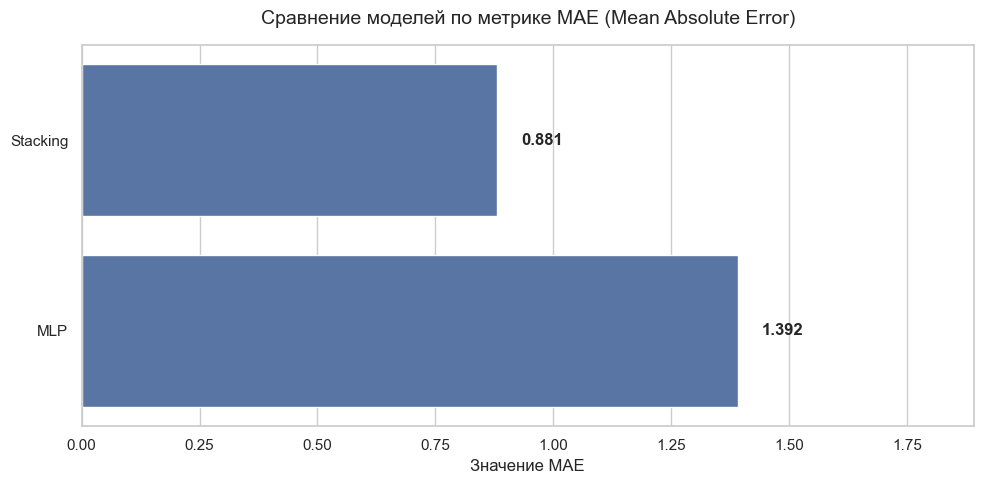

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Итоговые метрики моделей (MAE)
model_names = [
    'Stacking', 
    'MLP'
]
mae_scores = [mae_stack, mae_mlp]

# Настройка стиля графика
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

# Отрисовка горизонтального столбчатого графика
ax = sns.barplot(
    x=mae_scores, 
    y=model_names, 
)

# Добавление числовых значений на столбцы
for i, v in enumerate(mae_scores):
    ax.text(v + 0.05, i, f"{v:.3f}", va='center', fontweight='bold')

plt.title('Сравнение моделей по метрике MAE (Mean Absolute Error)', fontsize=14, pad=15)
plt.xlabel('Значение MAE', fontsize=12)
plt.xlim(0, max(mae_scores) + 0.5)

plt.tight_layout()
plt.show()

### 3. Метод группового учета аргументов

### 3.1 линейный алгоритм COMBI

In [39]:
!pip install gmdh

  Using cached gmdh-1.0.3.tar.gz (14.4 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached docstring_inheritance-3.0.0-py3-none-any.whl.metadata (10 kB)
Using cached docstring_inheritance-3.0.0-py3-none-any.whl (26 kB)
Failed to build gmdh


  error: subprocess-exited-with-error
  
  exit code: 1
  
  [119 lines of output]
  C:\Users\User\AppData\Local\Temp\pip-build-env-54dgs15x\overlay\Lib\site-packages\setuptools\dist.py:765: SetuptoolsDeprecationWarning: License classifiers are deprecated.
  !!
  
          ********************************************************************************
          Please consider removing the following classifiers in favor of a SPDX license expression:
  
          License :: OSI Approved :: Apache Software License
  
          See https://packaging.python.org/en/latest/guides/writing-pyproject-toml/#license for details.
          ********************************************************************************
  
  !!
    self._finalize_license_expression()
  running bdist_wheel
  running build
  running build_py
  creating build\lib.win-amd64-cpython-312\gmdh
  copying gmdh\gmdh.py -> build\lib.win-amd64-cpython-312\gmdh
  copying gmdh\version.py -> build\lib.win-amd64-cpython-312\gmdh

In [37]:
import gmdh

ModuleNotFoundError: No module named 'gmdh'

In [35]:
X_train_np = X_train.values
y_train_np = y_train.values
X_test_np = X_test.values

combi_model = gmdh.Combi()
combi_model.fit(np.array(X_train), np.array(y_train))

# Предсказание
y_pred_combi = combi_model.predict(np.array(X_test))

mae_combi = mean_absolute_error(y_test, y_pred_combi)
print(f'MAE для GMDH COMBI: {mae_combi:.4f}')

AttributeError: module 'gmdhpy.gmdh' has no attribute 'Combi'

### 3.2 нелинейный многорядный алгоритм MIA

In [36]:
# Инициализация и обучение модели MIA
mia_model = gmdh.Mia()
mia_model.fit(np.array(X_train), np.array(y_train))

# Предсказание
y_pred_mia = mia_model.predict(np.array(X_test))

mae_mia = mean_absolute_error(y_test, y_pred_mia)
print(f'MAE для GMDH MIA: {mae_mia:.4f}')

AttributeError: module 'gmdhpy.gmdh' has no attribute 'Mia'

## 5. Оценка качества моделей

In [12]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [13]:
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    print(f"Модель: {name}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  F1-score : {f1:.4f}\n")

In [34]:
def vis_models_quality(array_metric, array_labels, str_header, figsize=(7, 5)):
    fig, ax1 = plt.subplots(figsize=figsize)
    pos = np.arange(len(array_metric))
    rects = ax1.barh(pos, array_metric,
                     align='center',
                     height=0.5, 
                     tick_label=array_labels,
                     color='teal')
    ax1.set_title(str_header)
    for a,b in zip(pos, array_metric):
        # Немного сдвигаем текст для красоты
        plt.text(b + 0.01, a - 0.05, str(round(b, 4)), color='black')
    plt.xlabel("Mean Absolute Error (Меньше = лучше)")
    plt.show()

# Сбор результатов в массивы
array_labels = ['Stacking (RF+DT -> Ridge)', 'MLP (Neural Network)', 'GMDH COMBI', 'GMDH MIA']
array_mae = [mae_stack, mae_mlp, mae_combi, mae_mia]

# Вызов функции
vis_models_quality(array_mae, array_labels, 'Сравнение моделей (MAE)')

NameError: name 'mae_combi' is not defined